<a href="https://colab.research.google.com/github/ai-with-sam/LearnPandas/blob/main/Pandas_GroupBy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd

data = {
    'order_id': ['O1','O2','O3','O4','O5','O6','O7','O8'],
    'city': ['Mumbai','Delhi','Mumbai','Bangalore','Delhi','Mumbai','Delhi','Bangalore'],
    'category': ['Tech','Furniture','Tech','Office','Tech','Furniture','Office','Tech'],
    'sales': [25000, 8000, 15000, 3000, 32000, 12000, 5500, 18000],
    'profit': [5000, -500, 3200, 800, 8000, 1200, 600, 4000],
    'status': ['completed','completed','completed','cancelled','completed','completed','cancelled','completed']
}
df = pd.DataFrame(data)
print(df)

  order_id       city   category  sales  profit     status
0       O1     Mumbai       Tech  25000    5000  completed
1       O2      Delhi  Furniture   8000    -500  completed
2       O3     Mumbai       Tech  15000    3200  completed
3       O4  Bangalore     Office   3000     800  cancelled
4       O5      Delhi       Tech  32000    8000  completed
5       O6     Mumbai  Furniture  12000    1200  completed
6       O7      Delhi     Office   5500     600  cancelled
7       O8  Bangalore       Tech  18000    4000  completed


In [52]:
result = df[(df['sales']>20000)&(df['profit']>5000)]
result[['order_id', 'sales', 'profit']]

,order_id,sales,profit
4,O5,32000,8000


In [60]:
for city, sales in df.groupby('city'):
  print(city)
  print(sales)
  print()


Bangalore
  order_id       city category  sales  profit     status
3       O4  Bangalore   Office   3000     800  cancelled
7       O8  Bangalore     Tech  18000    4000  completed

Delhi
  order_id   city   category  sales  profit     status
1       O2  Delhi  Furniture   8000    -500  completed
4       O5  Delhi       Tech  32000    8000  completed
6       O7  Delhi     Office   5500     600  cancelled

Mumbai
  order_id    city   category  sales  profit     status
0       O1  Mumbai       Tech  25000    5000  completed
2       O3  Mumbai       Tech  15000    3200  completed
5       O6  Mumbai  Furniture  12000    1200  completed



In [64]:
df.groupby(['city', 'category'])['sales'].sum().sort_index(
    level=['city','category'],
    ascending=[True,False]
)

city       category 
Bangalore  Tech         18000
           Office        3000
Delhi      Tech         32000
           Office        5500
           Furniture     8000
Mumbai     Tech         40000
           Furniture    12000
Name: sales, dtype: int64

In [67]:
df.groupby("city")["sales"].agg(
    ["sum","mean","count","max","min"]
)

,sum,mean,count,max,min
city,,,,,
Bangalore,21000,10500.000000,2,18000,3000
Delhi,45500,15166.666667,3,32000,5500
Mumbai,52000,17333.333333,3,25000,12000


In [68]:
df.groupby("city").agg(
    sales_sum=("sales","sum"),
    profit_mean=("profit","mean"),
    total_orders=("order_id","count")
)

,sales_sum,profit_mean,total_orders
city,,,
Bangalore,21000,2400.000000,2
Delhi,45500,2700.000000,3
Mumbai,52000,3133.333333,3


In [69]:
df.groupby("city").agg({
    "sales":"sum",
    "profit":"sum",
    "order_id":"count"
})

,sales,profit,order_id
city,,,
Bangalore,21000,4800,2
Delhi,45500,8100,3
Mumbai,52000,9400,3


In [57]:
df.groupby(['city', 'category'])['sales'].sum().sort_index(level='category', ascending=False)

,,sales
city,category,
Mumbai,Tech,40000
Delhi,Tech,32000
Bangalore,Tech,18000
Delhi,Office,5500
Bangalore,Office,3000
Mumbai,Furniture,12000
Delhi,Furniture,8000


In [33]:
df.groupby(['city','category'])['order_id'].size()

city       category 
Bangalore  Office       1
           Tech         1
Delhi      Furniture    1
           Office       1
           Tech         1
Mumbai     Furniture    1
           Tech         2
Name: order_id, dtype: int64

In [34]:
df.groupby('city')['sales'].max()

,sales
city,
Bangalore,18000
Delhi,32000
Mumbai,25000


In [35]:
df.groupby('city')['sales'].mean()

,sales
city,
Bangalore,10500.000000
Delhi,15166.666667
Mumbai,17333.333333


In [36]:
df.groupby('city')['sales'].median()

,sales
city,
Bangalore,10500.0
Delhi,8000.0
Mumbai,15000.0


In [37]:
df

,order_id,city,category,sales,profit,status
0,O1,Mumbai,Tech,25000,5000,completed
1,O2,Delhi,Furniture,8000,-500,completed
2,O3,Mumbai,Tech,15000,3200,completed
3,O4,Bangalore,Office,3000,800,cancelled
4,O5,Delhi,Tech,32000,8000,completed
5,O6,Mumbai,Furniture,12000,1200,completed
6,O7,Delhi,Office,5500,600,cancelled
7,O8,Bangalore,Tech,18000,4000,completed


In [41]:
completed = df[df['status']=='completed']
completed.groupby('city')['sales'].sum()

,sales
city,
Bangalore,18000
Delhi,40000
Mumbai,52000


In [42]:
df[['sales','status']]

,sales,status
0,25000,completed
1,8000,completed
2,15000,completed
3,3000,cancelled
4,32000,completed
5,12000,completed
6,5500,cancelled
7,18000,completed


In [43]:
df.columns = df.columns.str.upper().str.strip()
df.columns


Index(['ORDER_ID', 'CITY', 'CATEGORY', 'SALES', 'PROFIT', 'STATUS'], dtype='object')

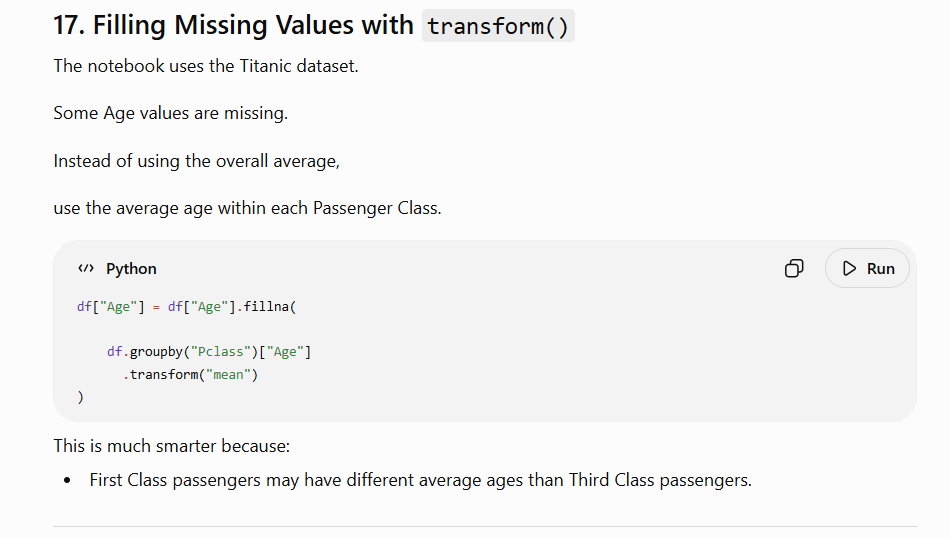

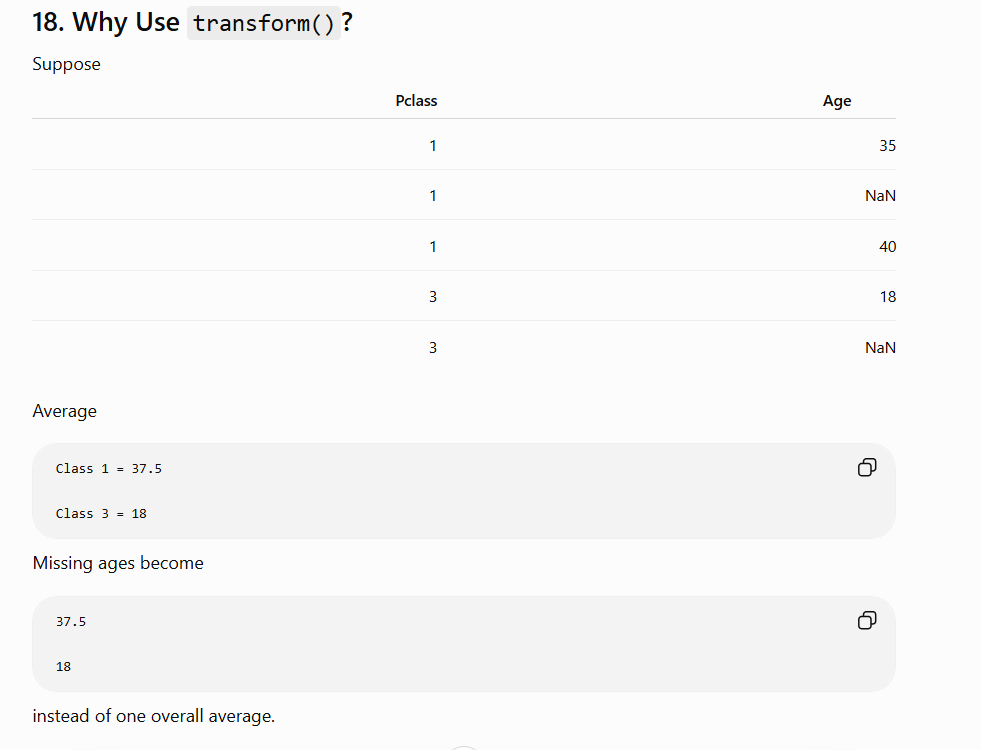